Heart Disease UCI - Full ML Analysis
=====================================
Steps:
  1. Load & preprocess
  2. Basic statistical check
  3. Correlation analysis
  4. PCA (95% variance threshold)
  5. K-Means clustering + elbow plot
  6. Random Forest + SVM to predict clusters
  7. Accuracy & confusion matrix comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [83]:
df = pd.read_csv("heart_disease_uci.csv")
print("Raw shape:", df.shape)

Raw shape: (920, 16)


In [84]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

for col in numerical_cols:
    print(f"\nFeature: {col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Range:", df[col].max() - df[col].min())


Feature: age
Minimum: 28
Maximum: 77
Range: 49

Feature: trestbps
Minimum: 0.0
Maximum: 200.0
Range: 200.0

Feature: chol
Minimum: 0.0
Maximum: 603.0
Range: 603.0

Feature: thalch
Minimum: 60.0
Maximum: 202.0
Range: 142.0

Feature: oldpeak
Minimum: -2.6
Maximum: 6.2
Range: 8.8


In [85]:
# Fill missing numerical values with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [86]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'bool':
        df[col] = le.fit_transform(df[col].astype(str))

print(df.head())

   id  age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   1   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   2   67    1        0   0     160.0  286.0    0        0   108.0      1   
2   3   67    1        0   0     120.0  229.0    0        0   129.0      1   
3   4   37    1        0   2     130.0  250.0    0        1   187.0      0   
4   5   41    0        0   1     130.0  204.0    0        0   172.0      0   

   oldpeak  slope   ca  thal  num  
0      2.3      0  0.0     0    0  
1      1.5      1  3.0     1    2  
2      2.6      1  2.0     2    1  
3      3.5      0  0.0     1    0  
4      1.4      2  0.0     1    0  


In [87]:
corr = X.corr()
print("\n" + "="*55)
print("TOP CORRELATIONS (|r| > 0.25)")
print("="*55)
pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.25:
            pairs.append((corr.columns[i], corr.columns[j], r))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in pairs:
    print(f"  {a:12s} ↔ {b:12s}  r = {r:+.3f}")


TOP CORRELATIONS (|r| > 0.25)
  id           ↔ dataset       r = +0.949
  ca           ↔ Cluster       r = +0.549
  id           ↔ restecg       r = +0.479
  dataset      ↔ restecg       r = +0.460
  thalch       ↔ Cluster       r = -0.444
  age          ↔ Cluster       r = +0.443
  id           ↔ thalch        r = -0.437
  oldpeak      ↔ Cluster       r = +0.435
  exang        ↔ Cluster       r = +0.430
  dataset      ↔ chol          r = -0.413
  dataset      ↔ thalch        r = -0.382
  exang        ↔ oldpeak       r = +0.382
  id           ↔ chol          r = -0.373
  cp           ↔ exang         r = -0.361
  age          ↔ thalch        r = -0.353
  thalch       ↔ exang         r = -0.350
  cp           ↔ Cluster       r = -0.347
  id           ↔ slope         r = -0.305
  dataset      ↔ slope         r = -0.297
  thal         ↔ Cluster       r = +0.291
  thalch       ↔ slope         r = +0.291
  cp           ↔ thalch        r = +0.289
  sex          ↔ dataset       r = +0.286
  i

In [88]:
corr_matrix = df.corr()

print(corr_matrix)

                id       age       sex   dataset        cp  trestbps  \
id        1.000000  0.239301  0.280053  0.949062 -0.189430  0.049369   
age       0.239301  1.000000  0.056889  0.235076 -0.076519  0.235253   
sex       0.280053  0.056889  1.000000  0.285734 -0.125933  0.001073   
dataset   0.949062  0.235076  0.285734  1.000000 -0.150334  0.019468   
cp       -0.189430 -0.076519 -0.125933 -0.150334  1.000000 -0.022565   
trestbps  0.049369  0.235253  0.001073  0.019468 -0.022565  1.000000   
chol     -0.372984 -0.084499 -0.193782 -0.412534  0.064510  0.088290   
fbs       0.148983  0.219915  0.075370  0.170110  0.006370  0.148398   
restecg   0.479012 -0.006652  0.072160  0.460189 -0.070150  0.015160   
thalch   -0.436795 -0.353471 -0.177135 -0.382415  0.289362 -0.104616   
exang     0.166239  0.160910  0.155204  0.129326 -0.360513  0.149040   
oldpeak   0.046473  0.248082  0.102733  0.048533 -0.173515  0.160268   
slope    -0.305000 -0.077087 -0.105805 -0.297152  0.113415 -0.05

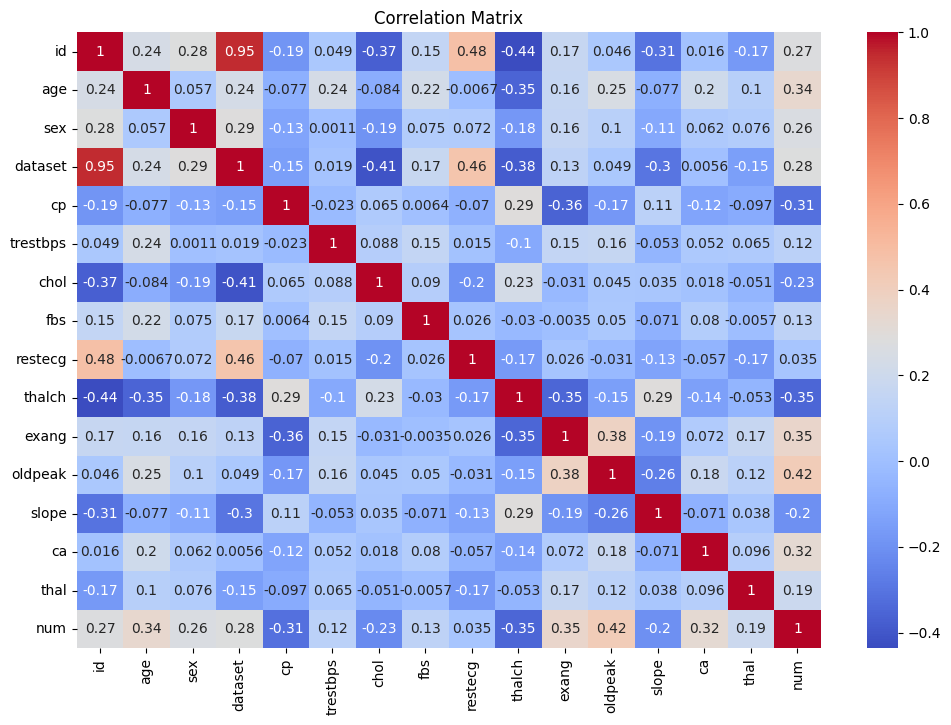

In [89]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

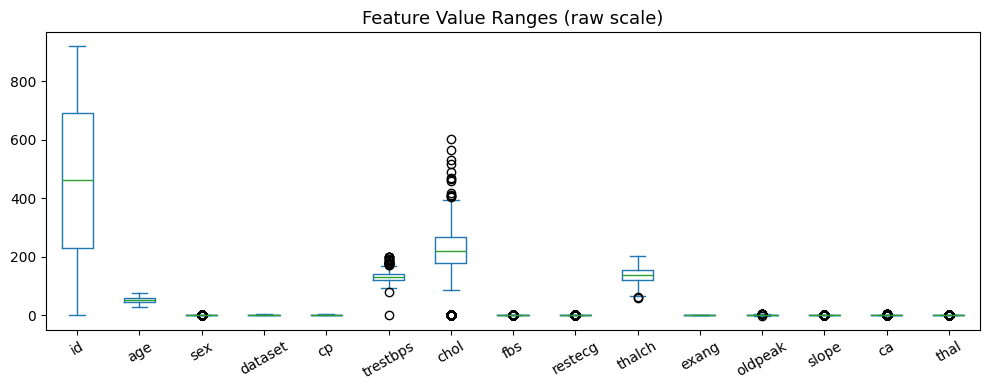

Saved: feature_ranges.png


In [90]:
# Separate features
X = df.drop('num', axis=1)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.figure(figsize=(10, 4))
X.plot(kind="box", ax=plt.gca(), rot=30)
plt.title("Feature Value Ranges (raw scale)", fontsize=13)
plt.tight_layout()
plt.savefig("feature_ranges.png", dpi=150)
plt.show()
print("Saved: feature_ranges.png")


PCA RESULTS
Components needed for 95% variance: 13
  PC 1: 22.46%  (cumulative: 22.46%)
  PC 2: 13.29%  (cumulative: 35.74%)
  PC 3:  8.82%  (cumulative: 44.57%)
  PC 4:  7.54%  (cumulative: 52.11%)
  PC 5:  6.45%  (cumulative: 58.56%)
  PC 6:  6.28%  (cumulative: 64.83%)
  PC 7:  5.87%  (cumulative: 70.70%)
  PC 8:  5.27%  (cumulative: 75.97%)
  PC 9:  5.03%  (cumulative: 81.00%)
  PC10:  4.78%  (cumulative: 85.79%)
  PC11:  4.11%  (cumulative: 89.90%)
  PC12:  3.70%  (cumulative: 93.60%)
  PC13:  3.34%  (cumulative: 96.94%) ← 95% threshold
  PC14:  2.76%  (cumulative: 99.69%)
  PC15:  0.31%  (cumulative: 100.00%)


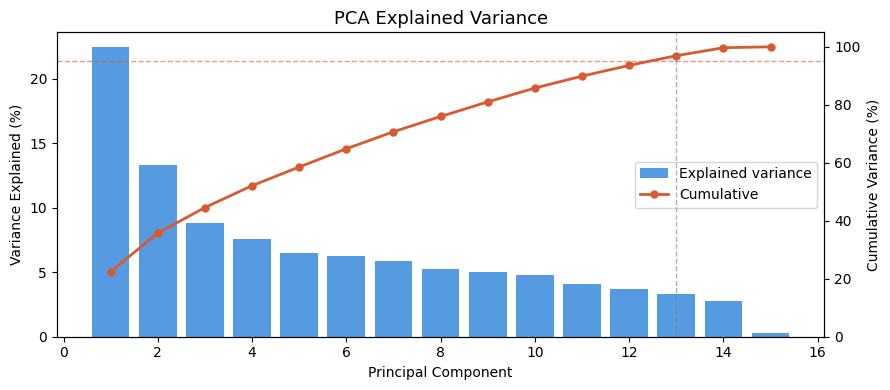

In [91]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumvar >= 0.95) + 1)
 
print("\n" + "="*55)
print("PCA RESULTS")
print("="*55)
print(f"Components needed for 95% variance: {n_components}")
for i, (ev, cv) in enumerate(zip(pca_full.explained_variance_ratio_, cumvar)):
    marker = " ← 95% threshold" if i + 1 == n_components else ""
    print(f"  PC{i+1:2d}: {ev*100:5.2f}%  (cumulative: {cv*100:5.2f}%){marker}")
 
# Plot PCA variance
fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(1, len(pca_full.explained_variance_ratio_) + 1)
ax.bar(x_pos, pca_full.explained_variance_ratio_ * 100,
       color="#378ADD", alpha=0.85, label="Explained variance")
ax2 = ax.twinx()
ax2.plot(x_pos, cumvar * 100, "o-", color="#D85A30",
         linewidth=2, markersize=5, label="Cumulative")
ax2.axhline(95, color="#D85A30", linestyle="--", linewidth=1, alpha=0.6)
ax2.axvline(n_components, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Explained (%)")
ax2.set_ylabel("Cumulative Variance (%)")
ax2.set_ylim(0, 105)
ax.set_title("PCA Explained Variance", fontsize=13)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()
 
# Apply PCA with chosen n_components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

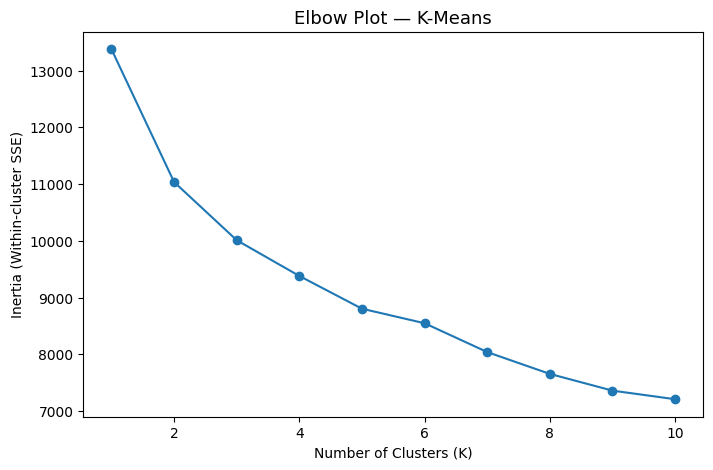

In [92]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Plot — K-Means", fontsize=13)
plt.savefig("elbow_plot.png", dpi=150)
plt.show()


Chosen K=3
Cluster distribution: [327, 190, 403]


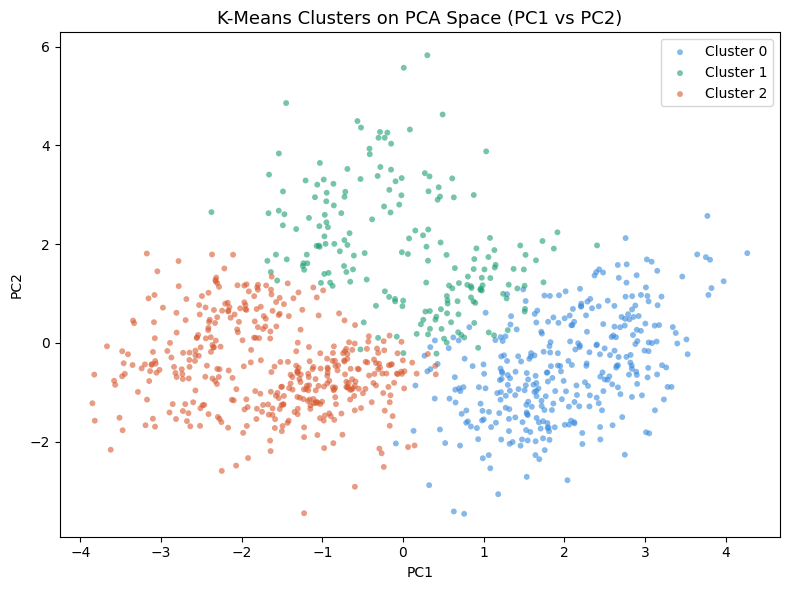

In [93]:
BEST_K = 3
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_pca)
print(f"\nChosen K={BEST_K}")
print(f"Cluster distribution: {np.bincount(cluster_labels).tolist()}")
 
# Scatter plot of clusters on PC1 vs PC2
plt.figure(figsize=(8, 6))
colors = ["#378ADD", "#1D9E75", "#D85A30"]
for c in range(BEST_K):
    mask = cluster_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[c], label=f"Cluster {c}",
                alpha=0.6, s=18, edgecolors="none")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA Space (PC1 vs PC2)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150)
plt.show()

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, cluster_labels,
    test_size=0.2, random_state=42, stratify=cluster_labels
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")


Train: 736  |  Test: 184


In [95]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)
 
print("\n" + "="*55)
print("RANDOM FOREST")
print("="*55)
print(f"Accuracy: {rf_acc*100:.2f}%")
print(f"\nConfusion Matrix:\n{rf_cm}")
print(f"\nClassification Report:\n{classification_report(y_test, rf_pred)}")
print("Random Forest Accuracy:", rf_acc)



RANDOM FOREST
Accuracy: 97.28%

Confusion Matrix:
[[64  0  1]
 [ 1 34  3]
 [ 0  0 81]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        65
           1       1.00      0.89      0.94        38
           2       0.95      1.00      0.98        81

    accuracy                           0.97       184
   macro avg       0.98      0.96      0.97       184
weighted avg       0.97      0.97      0.97       184

Random Forest Accuracy: 0.9728260869565217


In [96]:
svm = SVC(kernel="rbf", C=1.0, random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
svm_cm = confusion_matrix(y_test, svm_pred)
 
print("\n" + "="*55)
print("SVM (RBF KERNEL)")
print("="*55)
print(f"Accuracy: {svm_acc*100:.2f}%")
print(f"\nConfusion Matrix:\n{svm_cm}")
print(f"\nClassification Report:\n{classification_report(y_test, svm_pred)}")


SVM (RBF KERNEL)
Accuracy: 95.11%

Confusion Matrix:
[[63  1  1]
 [ 0 34  4]
 [ 1  2 78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        65
           1       0.92      0.89      0.91        38
           2       0.94      0.96      0.95        81

    accuracy                           0.95       184
   macro avg       0.95      0.94      0.94       184
weighted avg       0.95      0.95      0.95       184



In [97]:
print("Random Forest Accuracy:", rf_acc)
print("SVM Accuracy:", svm_acc)

Random Forest Accuracy: 0.9728260869565217
SVM Accuracy: 0.9510869565217391


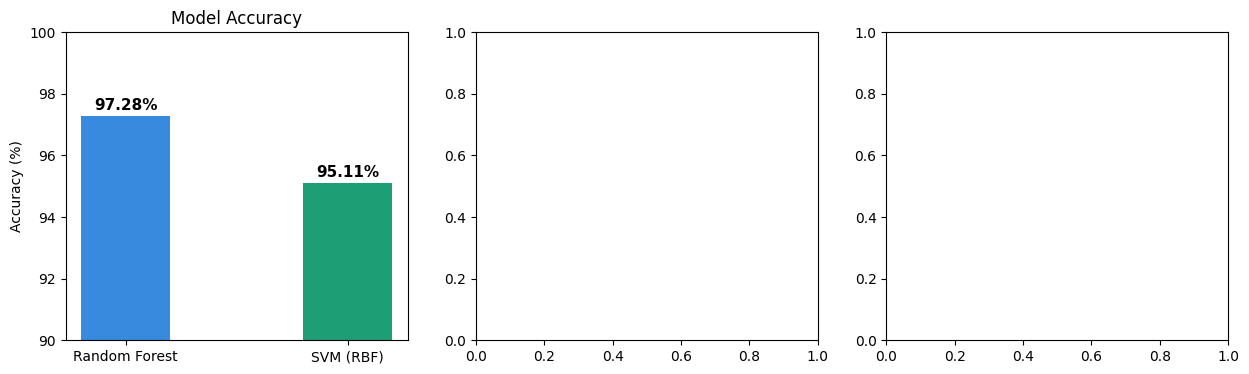

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(["Random Forest", "SVM (RBF)"],
            [rf_acc * 100, svm_acc * 100],
            color=["#378ADD", "#1D9E75"], width=0.4)
axes[0].set_ylim(90, 100)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Model Accuracy")
for i, v in enumerate([rf_acc, svm_acc]):
    axes[0].text(i, v * 100 + 0.1, f"{v*100:.2f}%",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

In [100]:
# RF confusion matrix
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues",
            ax=axes[1], cbar=False,
            xticklabels=["C0", "C1", "C2"],
            yticklabels=["C0", "C1", "C2"])
axes[1].set_title(f"Random Forest CM  ({rf_acc*100:.1f}%)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
 
# SVM confusion matrix
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Greens",
            ax=axes[2], cbar=False,
            xticklabels=["C0", "C1", "C2"],
            yticklabels=["C0", "C1", "C2"])
axes[2].set_title(f"SVM CM  ({svm_acc*100:.1f}%)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
 
plt.suptitle("Model Comparison — Cluster Classification", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

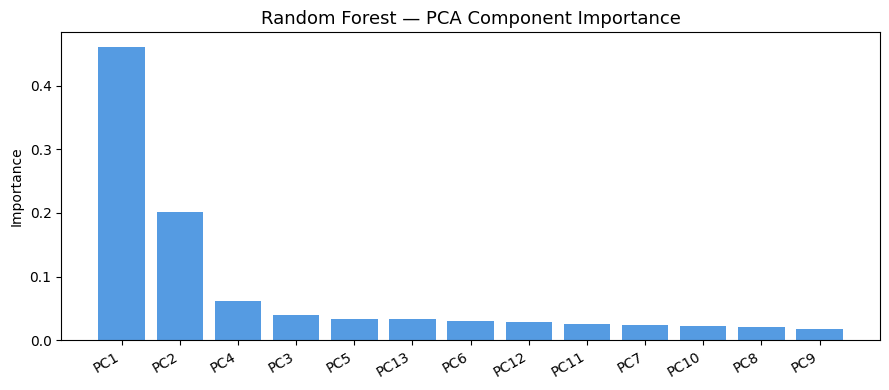

In [102]:
importances = rf.feature_importances_
pca_feat_names = [f"PC{i+1}" for i in range(n_components)]
sorted_idx = np.argsort(importances)[::-1]
plt.figure(figsize=(9, 4))
plt.bar(range(n_components),
        importances[sorted_idx],
        color="#378ADD", alpha=0.85)
plt.xticks(range(n_components),
           [pca_feat_names[i] for i in sorted_idx], rotation=30, ha="right")
plt.ylabel("Importance")
plt.title("Random Forest — PCA Component Importance", fontsize=13)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)

In [103]:
print("\n" + "="*55)
print("FINAL SUMMARY")
print("="*55)
print(f"  Clean samples          : {len(X)}")
print(f"  PCA components (95%)   : {n_components}")
print(f"  Optimal K (elbow)      : {BEST_K}")
print(f"  Cluster sizes          : {np.bincount(cluster_labels).tolist()}")
print(f"  Random Forest accuracy : {rf_acc*100:.2f}%")
print(f"  SVM accuracy           : {svm_acc*100:.2f}%")
print(f"  Winner                 : {'SVM' if svm_acc > rf_acc else 'Random Forest'}")


FINAL SUMMARY
  Clean samples          : 920
  PCA components (95%)   : 13
  Optimal K (elbow)      : 3
  Cluster sizes          : [327, 190, 403]
  Random Forest accuracy : 97.28%
  SVM accuracy           : 95.11%
  Winner                 : Random Forest
